# Correct-answer ROC AUC dynamics

This notebook tracks how well the student's single-token answer entropy separates correct from incorrect MMLU answers over training. A correct answer is the positive class, and negative entropy is used as the score so that lower entropy means greater estimated likelihood of correctness.

The comparison includes the three entropy-based strategies that re-estimate complexity every epoch: `entropy_gain`, `entropy_gain_proportional`, and `student_entropy`. One-shot and random-estimator runs are intentionally excluded because they cannot provide entropy ROC AUC dynamics.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score

for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    source_dir = directory / "src"
    if (source_dir / "core").is_dir():
        sys.path.insert(0, str(source_dir))
        break
else:
    raise FileNotFoundError("Could not find the repository's src/core directory")

from core.utils.graph_style import set_style

set_style()

ARTIFACT_GROUP = "distillation_by_metrics/mmlu"
EXPERIMENTS = ("entropy_gain", "entropy_gain_proportional", "student_entropy")
SCORE_COLUMN = "entropy_value"
CORRECTNESS_COLUMN = "estimation_phase_answer_correctness"
EXPECTED_EPOCHS = set(range(100))

EXPERIMENT_LABELS = {
    "entropy_gain": "Entropy gain",
    "entropy_gain_proportional": "Entropy gain proportional",
    "student_entropy": "Student entropy",
}
MODEL_LABELS = {
    "llama_3b_head_truncated8192": "Llama 3B",
    "phi4_mini_head_truncated8192": "Phi-4 Mini",
    "qwen_3b_head_truncated8192": "Qwen 3B",
}

In [2]:
def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk upward from the current directory until artifacts/ is found."""
    start = (start or Path.cwd()).resolve()
    for directory in (start, *start.parents):
        candidate = directory / "artifacts"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find artifacts/ above {start}")


def load_roc_auc_dynamics(group_dir: Path) -> tuple[pd.DataFrame, list[str]]:
    """Load every selected run/epoch and calculate ROC AUC for a correct answer."""
    records = []
    skipped = []

    for experiment in EXPERIMENTS:
        experiment_dir = group_dir / experiment
        if not experiment_dir.is_dir():
            raise FileNotFoundError(f"Missing experiment directory: {experiment_dir}")

        for model_dir in sorted(path for path in experiment_dir.iterdir() if path.is_dir()):
            parquet_paths = sorted(
                model_dir.glob("resampling_trainer_data/*/complexity_estimation/*.parquet"),
                key=lambda path: int(path.parents[1].name),
            )
            for parquet_path in parquet_paths:
                epoch = int(parquet_path.parents[1].name)
                epoch_df = pd.read_parquet(
                    parquet_path, columns=[CORRECTNESS_COLUMN, SCORE_COLUMN]
                ).dropna(subset=[CORRECTNESS_COLUMN, SCORE_COLUMN])

                if epoch_df.empty:
                    skipped.append(f"{experiment}/{model_dir.name}/epoch {epoch}: no valid rows")
                    continue

                answer_correct = epoch_df[CORRECTNESS_COLUMN].astype(bool).astype(int)
                correctness_score = -epoch_df[SCORE_COLUMN]
                if answer_correct.nunique() != 2:
                    skipped.append(
                        f"{experiment}/{model_dir.name}/epoch {epoch}: target has one class"
                    )
                    continue

                records.append(
                    {
                        "experiment": experiment,
                        "model": model_dir.name,
                        "epoch": epoch,
                        "roc_auc": roc_auc_score(answer_correct, correctness_score),
                        "num_valid": len(epoch_df),
                        "accuracy": answer_correct.mean(),
                        "target_classes": answer_correct.nunique(),
                    }
                )

    return pd.DataFrame.from_records(records).sort_values(
        ["model", "experiment", "epoch"]
    ).reset_index(drop=True), skipped


ARTIFACTS_DIR = find_artifacts_dir()
GROUP_DIR = ARTIFACTS_DIR / ARTIFACT_GROUP
roc_auc_by_epoch, skipped_epochs = load_roc_auc_dynamics(GROUP_DIR)
print(f"Loaded {len(roc_auc_by_epoch):,} epoch metrics from {GROUP_DIR}")
if skipped_epochs:
    print(f"Skipped {len(skipped_epochs)} invalid epoch(s):")
    print("\n".join(skipped_epochs))

Loaded 900 epoch metrics from /Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_by_metrics/mmlu


In [3]:
models = sorted(roc_auc_by_epoch["model"].unique())
expected_runs = {(experiment, model) for experiment in EXPERIMENTS for model in MODEL_LABELS}
observed_runs = set(roc_auc_by_epoch[["experiment", "model"]].itertuples(index=False, name=None))

assert not skipped_epochs, "Every selected epoch should have usable two-class data"
assert set(models) == set(MODEL_LABELS), f"Unexpected models: {models}"
assert observed_runs == expected_runs, f"Unexpected run set: {observed_runs}"
assert len(roc_auc_by_epoch) == len(EXPERIMENTS) * len(MODEL_LABELS) * len(EXPECTED_EPOCHS)
assert pd.api.types.is_integer_dtype(roc_auc_by_epoch["epoch"])
assert roc_auc_by_epoch["roc_auc"].between(0, 1).all()
assert roc_auc_by_epoch["num_valid"].gt(0).all()
assert roc_auc_by_epoch["target_classes"].eq(2).all()
for _, run in roc_auc_by_epoch.groupby(["experiment", "model"]):
    assert set(run["epoch"]) == EXPECTED_EPOCHS

print("Validated 3 models × 3 strategies × 100 complete epochs.")

Validated 3 models × 3 strategies × 100 complete epochs.


In [4]:
summary = (
    roc_auc_by_epoch.sort_values("epoch")
    .groupby(["model", "experiment"], as_index=False)
    .agg(
        initial_roc_auc=("roc_auc", "first"),
        final_roc_auc=("roc_auc", "last"),
        peak_roc_auc=("roc_auc", "max"),
        min_valid_samples=("num_valid", "min"),
    )
)
summary["model"] = summary["model"].map(MODEL_LABELS)
summary["experiment"] = summary["experiment"].map(EXPERIMENT_LABELS)
display(
    summary.rename(
        columns={"model": "Model", "experiment": "Strategy"}
    ).style.format(
        {
            "initial_roc_auc": "{:.3f}",
            "final_roc_auc": "{:.3f}",
            "peak_roc_auc": "{:.3f}",
            "min_valid_samples": "{:,.0f}",
        }
    )
)

,Model,Strategy,initial_roc_auc,final_roc_auc,peak_roc_auc,min_valid_samples
0,Llama 3B,Entropy gain,0.708,0.663,0.785,"9,567"
1,Llama 3B,Entropy gain proportional,0.708,0.846,0.868,"9,610"
2,Llama 3B,Student entropy,0.709,0.473,0.731,"9,623"
3,Phi-4 Mini,Entropy gain,0.732,0.658,0.796,"9,626"
4,Phi-4 Mini,Entropy gain proportional,0.735,0.828,0.871,"9,625"
5,Phi-4 Mini,Student entropy,0.732,0.483,0.763,"9,626"
6,Qwen 3B,Entropy gain,0.711,0.622,0.770,"6,586"
7,Qwen 3B,Entropy gain proportional,0.711,0.872,0.886,"8,381"
8,Qwen 3B,Student entropy,0.710,0.510,0.779,"9,005"


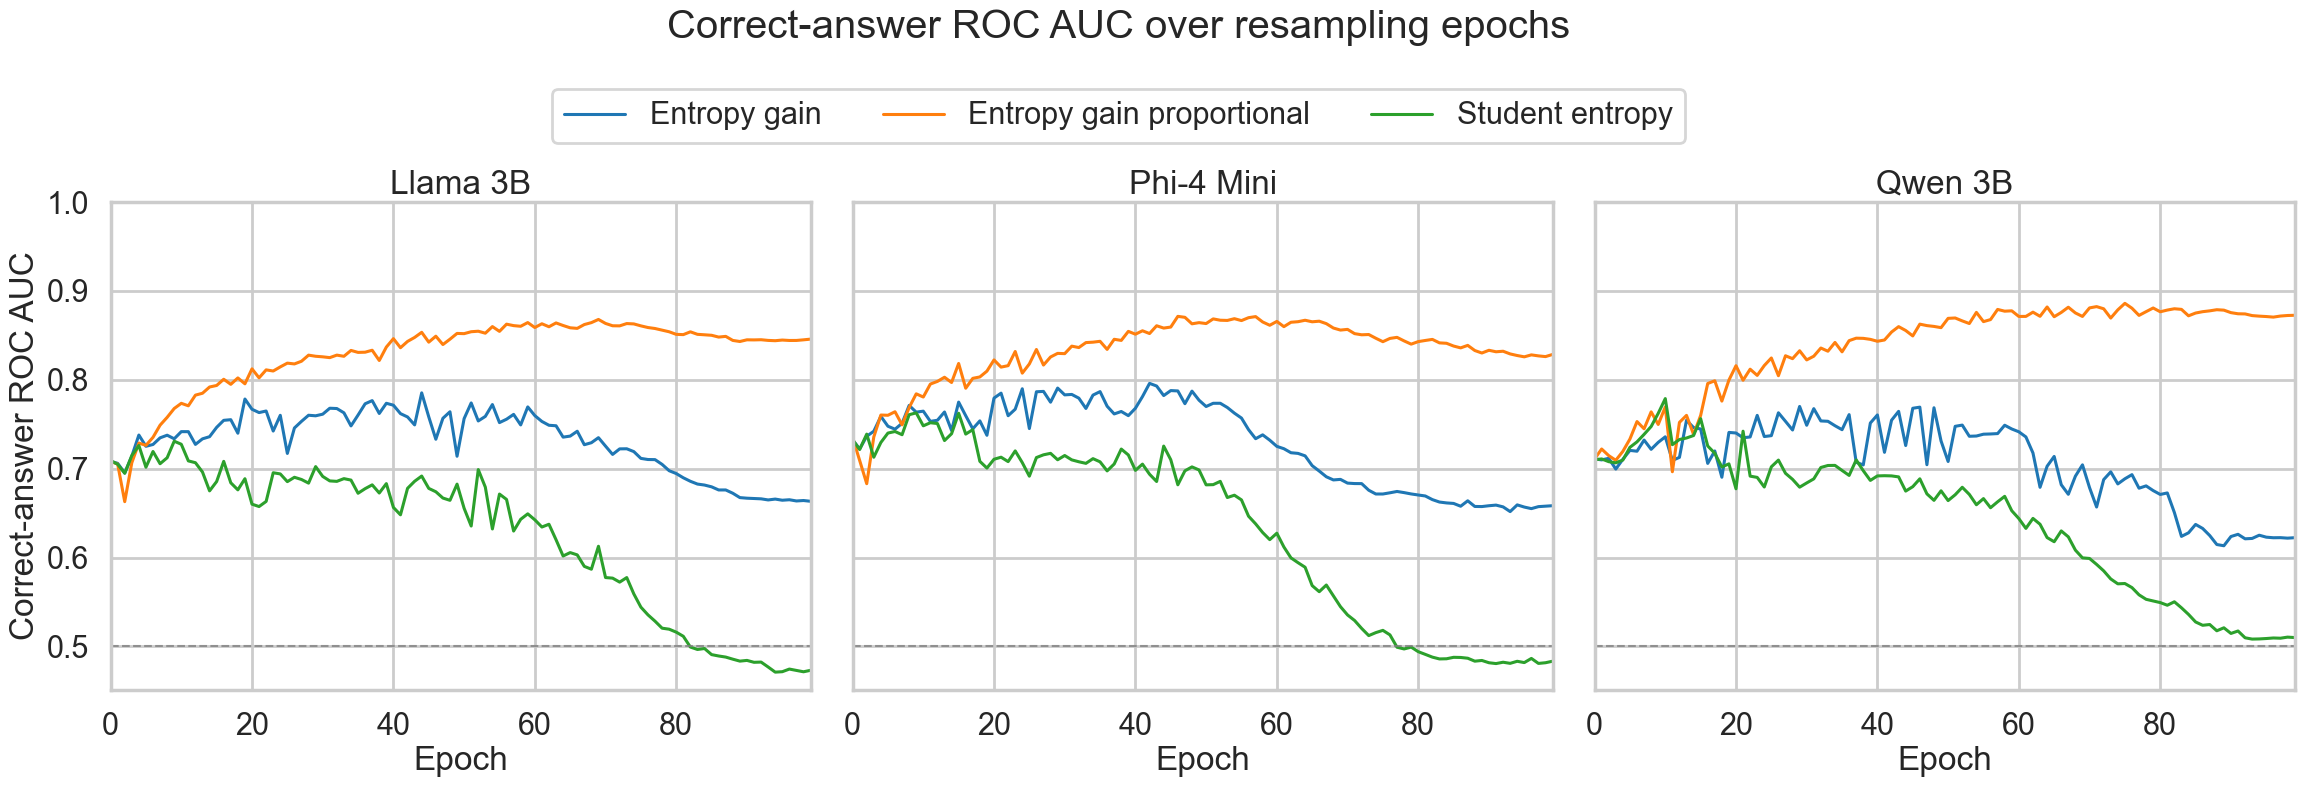

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(24, 8), sharex=True, sharey=True)
colors = {experiment: plt.get_cmap("tab10")(i) for i, experiment in enumerate(EXPERIMENTS)}

for ax, model in zip(axes, models, strict=True):
    model_data = roc_auc_by_epoch[roc_auc_by_epoch["model"] == model]
    for experiment in EXPERIMENTS:
        curve = model_data[model_data["experiment"] == experiment]
        ax.plot(
            curve["epoch"],
            curve["roc_auc"],
            color=colors[experiment],
            linewidth=2.2,
            label=EXPERIMENT_LABELS[experiment],
        )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("Epoch")
    ax.set_xlim(min(EXPECTED_EPOCHS), max(EXPECTED_EPOCHS))

axes[0].set_ylabel("Correct-answer ROC AUC")
lower_limit = min(0.48, roc_auc_by_epoch["roc_auc"].min() - 0.02)
axes[0].set_ylim(lower_limit, 1.0)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(EXPERIMENTS), bbox_to_anchor=(0.5, 0.91))
fig.suptitle("Correct-answer ROC AUC over resampling epochs", y=0.99)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.14, top=0.75, wspace=0.06)

assert sum(len(ax.lines) - 1 for ax in axes) == 9  # exclude each subplot's chance baseline
plt.show()